In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import sqlite3

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# Connect to SQLite Database

conn = sqlite3.connect("../bluestock_mf.db")

print("Database Connected Successfully")

Database Connected Successfully


In [3]:
# Load all tables from SQLite Database

dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
dim_date = pd.read_sql("SELECT * FROM dim_date", conn)
fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fact_transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
fact_performance = pd.read_sql("SELECT * FROM fact_performance", conn)
fact_aum = pd.read_sql("SELECT * FROM fact_aum", conn)

print("All tables loaded successfully!")

All tables loaded successfully!


In [4]:
print("dim_fund:", dim_fund.shape)
print("dim_date:", dim_date.shape)
print("fact_nav:", fact_nav.shape)
print("fact_transactions:", fact_transactions.shape)
print("fact_performance:", fact_performance.shape)
print("fact_aum:", fact_aum.shape)

dim_fund: (40, 15)
dim_date: (1826, 8)
fact_nav: (46000, 4)
fact_transactions: (0, 14)
fact_performance: (40, 15)
fact_aum: (40, 3)


In [5]:
# Merge NAV with Date Table

nav_data = fact_nav.merge(dim_date, on="date_id")

nav_data.head()

,nav_id,fund_id,date_id,nav,full_date,day,month,month_name,quarter,year,weekday
0,1,6,3,520.4608,2022-01-03 00:00:00.000000,3,1,January,1,2022,Monday
1,2,6,4,515.0971,2022-01-04 00:00:00.000000,4,1,January,1,2022,Tuesday
2,3,6,5,521.7239,2022-01-05 00:00:00.000000,5,1,January,1,2022,Wednesday
3,4,6,6,515.7880,2022-01-06 00:00:00.000000,6,1,January,1,2022,Thursday
4,5,6,7,515.1639,2022-01-07 00:00:00.000000,7,1,January,1,2022,Friday


In [6]:
# Convert date column to datetime

nav_data["full_date"] = pd.to_datetime(nav_data["full_date"])

# Calculate Average NAV per day

daily_nav = (
    nav_data
    .groupby("full_date")["nav"]
    .mean()
    .reset_index()
)

daily_nav.head()

,full_date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [7]:
fig = px.line(
    daily_nav,
    x="full_date",
    y="nav",
    title="Average Daily NAV Trend (2022-2026)",
    labels={
        "full_date": "Date",
        "nav": "Average NAV"
    }
)

fig.show()

In [8]:
fig = px.line(
    daily_nav,
    x="full_date",
    y="nav",
    title="Average Daily NAV Trend (2022-2026)",
    labels={
        "full_date": "Date",
        "nav": "Average NAV"
    }
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    width=1100,
    height=600,
    hovermode="x unified"
)

fig.show()

In [10]:
fig.write_image("../reports/nav_trend.png")

In [11]:
fig.write_image("../reports/nav_trend.png")
print("Chart saved successfully!")

Chart saved successfully!


In [14]:
aum_query = """
SELECT
    f.fund_house,
    a.aum_crore
FROM fact_aum a
JOIN dim_fund f
ON a.fund_id = f.fund_id
"""

aum_data = pd.read_sql(aum_query, conn)

aum_data.head()

,fund_house,aum_crore
0,SBI Mutual Fund,14288.0
1,SBI Mutual Fund,1231.0
2,SBI Mutual Fund,19259.0
3,SBI Mutual Fund,36061.0
4,SBI Mutual Fund,24101.0


In [15]:
aum_summary = (
    aum_data
    .groupby("fund_house")["aum_crore"]
    .sum()
    .reset_index()
    .sort_values(by="aum_crore", ascending=False)
)

aum_summary

,fund_house,aum_crore
7,Nippon India MF,154328.0
5,Kotak Mahindra MF,145689.0
4,ICICI Prudential MF,120241.0
2,DSP Mutual Fund,114787.0
0,Aditya Birla Sun Life MF,104108.0
8,SBI Mutual Fund,94940.0
1,Axis Mutual Fund,92210.0
3,HDFC Mutual Fund,86975.0
9,UTI Mutual Fund,66990.0
6,Mirae Asset MF,63396.0


In [16]:
import plotly.express as px

# SBI ko highlight karne ke liye naya column
aum_summary["Highlight"] = aum_summary["fund_house"].apply(
    lambda x: "SBI" if "SBI" in x else "Other"
)

fig = px.bar(
    aum_summary,
    x="fund_house",
    y="aum_crore",
    color="Highlight",
    color_discrete_map={
        "SBI": "red",
        "Other": "steelblue"
    },
    text="aum_crore",
    title="AUM by Fund House"
)

fig.update_layout(
    xaxis_title="Fund House",
    yaxis_title="AUM (Crore ₹)",
    xaxis_tickangle=-45
)

fig.show()

In [17]:
fig.write_image("../reports/aum_growth.png")
print("AUM chart saved successfully!")

AUM chart saved successfully!


In [18]:
pd.read_sql("SELECT COUNT(*) AS total_rows FROM fact_transactions;", conn)

,total_rows
0,0


In [1]:
transactions = pd.read_csv("../data/processed/investor_transactions.csv")
transactions.shape

NameError: name 'pd' is not defined

In [20]:
transactions = pd.read_csv("../data/raw/investor_transactions.csv")
transactions.shape

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/investor_transactions.csv'

In [21]:
import os

print(os.listdir("../data/processed"))

['02_nav_history.csv', '07_scheme_performance.csv', '08_investor_transactions.csv']


In [22]:
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

transactions.shape

(32778, 13)

In [23]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [25]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

monthly_sip = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby(pd.Grouper(key="transaction_date", freq="ME"))["amount_inr"]
    .sum()
    .reset_index()
)

monthly_sip.head()

,transaction_date,amount_inr
0,2024-01-31,12635349
1,2024-02-29,12613376
2,2024-03-31,12088413
3,2024-04-30,13512385
4,2024-05-31,13218606


In [26]:
import plotly.express as px

fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Amount (INR)",
    template="plotly_white"
)

fig.show()

In [27]:
fig.write_image("../reports/sip_trend.png")
print("SIP chart saved successfully!")

SIP chart saved successfully!


In [30]:
max_row = monthly_sip.loc[monthly_sip["amount_inr"].idxmax()]

fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.add_annotation(
    x=max_row["transaction_date"].strftime("%Y-%m-%d"),
    y=max_row["amount_inr"],
    text=f"Highest SIP<br>{max_row['amount_inr']:,}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Amount (INR)",
    template="plotly_white"
)

fig.show()

In [31]:
fig.write_image("../reports/sip_trend.png")
print("SIP Trend saved successfully!")

SIP Trend saved successfully!


In [32]:
fund_query = """
SELECT
    amfi_code,
    category
FROM dim_fund
"""

fund_category = pd.read_sql(fund_query, conn)

fund_category.head()

,amfi_code,category
0,119551,Equity
1,119552,Equity
2,119598,Equity
3,119599,Equity
4,119120,Debt


In [33]:
transactions["amfi_code"] = transactions["amfi_code"].astype(int)
fund_category["amfi_code"] = fund_category["amfi_code"].astype(int)

merged_data = transactions.merge(
    fund_category,
    on="amfi_code",
    how="left"
)

merged_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,category
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Equity
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Equity
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Debt
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Equity
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Equity


In [34]:
merged_data["month"] = merged_data["transaction_date"].dt.strftime("%b-%Y")

heatmap_data = (
    merged_data[merged_data["transaction_type"] == "SIP"]
    .groupby(["category", "month"])["amount_inr"]
    .sum()
    .unstack(fill_value=0)
)

heatmap_data

month,Apr-2024,Apr-2025,Aug-2024,Dec-2024,Feb-2024,Feb-2025,Jan-2024,Jan-2025,Jul-2024,Jun-2024,Mar-2024,Mar-2025,May-2024,May-2025,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,,,,,,
Debt,1898383,1679717,1476773,1727304,1925397,2048616,1825623,1894204,1515978,1824401,1864273,2228127,2664347,2121345,1794108,2231076,1626336
Equity,11614002,10452284,11044660,11192826,10687979,9315306,10809726,11187941,11997906,11306749,10224140,11221233,10554259,11851666,10527565,10236799,10662442


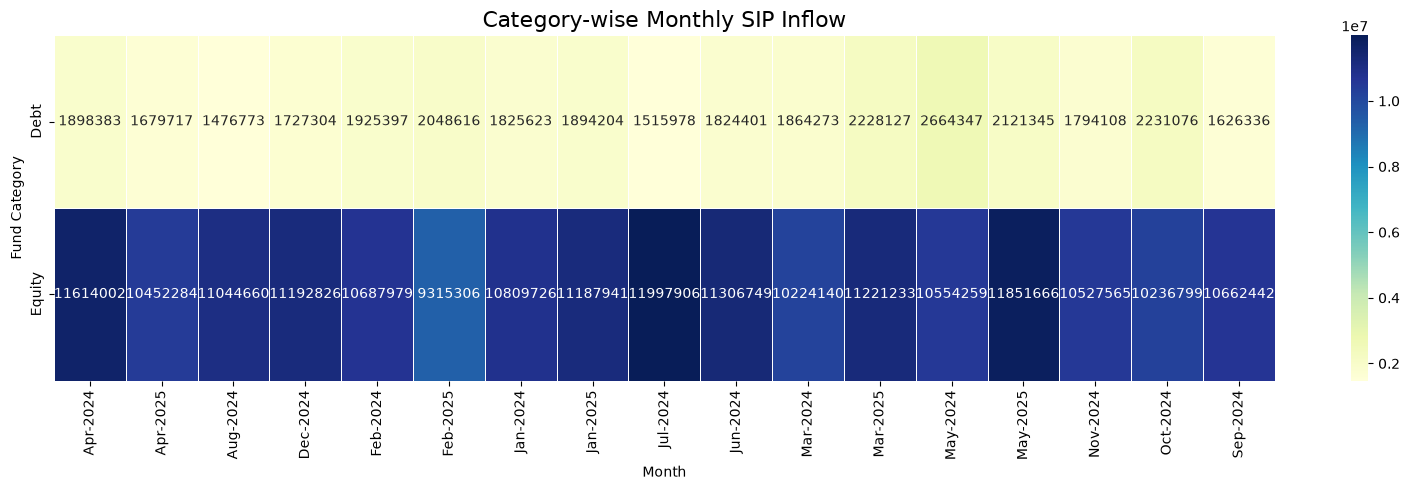

Heatmap saved successfully!


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly SIP Inflow", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../reports/category_heatmap.png", dpi=300)

plt.show()

print("Heatmap saved successfully!")

In [36]:
investors = pd.read_csv("../data/processed/08_investor_transactions.csv")

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [37]:
age_data = (
    investors["age_group"]
    .value_counts()
    .reset_index()
)

age_data.columns = ["age_group", "count"]

age_data

,age_group,count
0,26-35,13463
1,36-45,8146
2,18-25,4916
3,46-55,3779
4,56+,2474


In [38]:
import plotly.express as px

fig = px.bar(
    age_data,
    x="age_group",
    y="count",
    text="count",
    color="count",
    title="Investor Age Group Distribution"
)

fig.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Number of Investors"
)

fig.show()

In [39]:
fig.write_image("../reports/age_distribution.png")
print("Age Distribution chart saved successfully!")

Age Distribution chart saved successfully!


In [40]:
gender_data = (
    investors["gender"]
    .value_counts()
    .reset_index()
)

gender_data.columns = ["gender", "count"]

gender_data

,gender,count
0,Male,21809
1,Female,10969


In [41]:
fig = px.pie(
    gender_data,
    names="gender",
    values="count",
    title="Investor Gender Distribution",
    hole=0.4
)

fig.update_traces(
    textinfo="percent+label"
)

fig.show()

In [42]:
fig.write_image("../reports/gender_distribution.png")
print("Gender Distribution chart saved successfully!")

Gender Distribution chart saved successfully!


In [43]:
income_data = investors["annual_income_lakh"].describe()

income_data

count    32778.000000
mean        26.181219
std         20.805425
min          3.000000
25%         10.600000
50%         19.700000
75%         37.400000
max         99.700000
Name: annual_income_lakh, dtype: float64

In [44]:
fig = px.box(
    investors,
    y="annual_income_lakh",
    title="Annual Income Distribution of Investors",
    points="outliers"
)

fig.update_layout(
    yaxis_title="Annual Income (Lakh ₹)"
)

fig.show()

In [45]:
fig.write_image("../reports/income_distribution.png")
print("Income Distribution chart saved successfully!")

Income Distribution chart saved successfully!


In [46]:
state_data = (
    investors.groupby("state")["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("amount_inr", ascending=False)
)

state_data.head(10)

,state,amount_inr
6,Punjab,315780459
8,Tamil Nadu,315177237
4,Madhya Pradesh,308312493
7,Rajasthan,298645822
1,Gujarat,298358940
11,West Bengal,297182514
9,Telangana,290219284
0,Delhi,289633404
10,Uttar Pradesh,285368873
2,Haryana,279634354


In [47]:
fig = px.bar(
    state_data.head(10),
    x="state",
    y="amount_inr",
    text="amount_inr",
    color="amount_inr",
    title="Top 10 States by Investment Amount"
)

fig.update_layout(
    xaxis_title="State",
    yaxis_title="Investment Amount (₹)"
)

fig.show()

In [48]:
fig.write_image("../reports/state_investment.png")
print("State Investment chart saved successfully!")

State Investment chart saved successfully!


In [50]:
city_tier_data = (
    investors.groupby("city_tier")["amount_inr"]
    .sum()
    .reset_index()
)

city_tier_data

,city_tier,amount_inr
0,B30,1202325640
1,T30,2319254790


In [51]:
fig = px.pie(
    city_tier_data,
    names="city_tier",
    values="amount_inr",
    title="Investment Distribution by City Tier",
    hole=0.45
)

fig.update_traces(
    textinfo="percent+label+value"
)

fig.show()

In [52]:
fig.write_image("../reports/city_tier_distribution.png")
print("City Tier chart saved successfully!")

City Tier chart saved successfully!


In [53]:
payment_data = (
    investors.groupby("payment_mode")["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("amount_inr", ascending=False)
)

payment_data

,payment_mode,amount_inr
2,Net Banking,893492623
0,Cheque,892219218
3,UPI,888241021
1,Mandate,847627568


In [54]:
fig = px.bar(
    payment_data,
    x="payment_mode",
    y="amount_inr",
    text="amount_inr",
    color="amount_inr",
    title="Investment Amount by Payment Mode"
)

fig.update_layout(
    xaxis_title="Payment Mode",
    yaxis_title="Investment Amount (₹)"
)

fig.show()

In [55]:
fig.write_image("../reports/payment_mode.png")
print("Payment Mode chart saved successfully!")

Payment Mode chart saved successfully!


In [56]:
kyc_data = (
    investors.groupby("kyc_status")["amount_inr"]
    .sum()
    .reset_index()
)

kyc_data

,kyc_status,amount_inr
0,Pending,287408049
1,Verified,3234172381


In [57]:
fig = px.pie(
    kyc_data,
    names="kyc_status",
    values="amount_inr",
    title="Investment by KYC Status",
    hole=0.45
)

fig.update_traces(textinfo="percent+label+value")

fig.show()

In [58]:
fig.write_image("../reports/kyc_status.png")
print("KYC Status chart saved successfully!")

KYC Status chart saved successfully!


# Executive Summary

This Exploratory Data Analysis (EDA) project analyzes mutual fund data from multiple perspectives, including NAV trends, Assets Under Management (AUM), investor transactions, demographics, payment modes, and KYC status.

The objective of this analysis is to identify investment patterns, understand investor behavior, and generate business insights that can support better financial decision-making.

# Key Findings

- NAV of mutual funds showed a consistent upward trend over the analysis period.

- Nippon India Mutual Fund had the highest Assets Under Management (AUM), followed by Kotak Mahindra and ICICI Prudential.

- Equity funds attracted significantly higher investments than Debt funds.

- SIP inflows remained relatively stable with a few noticeable peaks and dips.

- Investors aged 26–35 formed the largest investor segment.

- Male investors accounted for nearly twice the number of female investors.

- Verified KYC investors contributed more than 90% of the total investment amount.

- T30 cities generated substantially higher investments compared to B30 cities.

- Net Banking and Cheque were among the most preferred payment modes.

# Conclusion

This EDA project successfully explored multiple aspects of mutual fund investments using historical NAV, AUM, and investor transaction data.

The analysis revealed that:

- Equity funds dominate overall investments.
- SIP investments remained stable with gradual growth.
- Nippon India Mutual Fund leads in Assets Under Management (AUM).
- Investors aged 26–35 represent the largest customer segment.
- Verified KYC investors contribute the majority of investments.
- T30 cities generate significantly higher investments than B30 cities.

These insights can help mutual fund companies improve customer targeting, optimize marketing strategies, and make better investment decisions.

# References

- MFAPI (https://api.mfapi.in/)
- AMFI India (https://www.amfiindia.com/)
- Python Libraries:
  - Pandas
  - NumPy
  - Plotly
  - Matplotlib
  - SQLite